In [1]:
import numpy as np

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.preprocessing import load_csv_with_headers

headers, data = load_csv_with_headers('../data/Raisin_Dataset.csv')

print(headers)

['\ufeffArea' 'MajorAxisLength' 'MinorAxisLength' 'Eccentricity'
 'ConvexArea' 'Extent' 'Perimeter' 'Class']


### Testing preprocessing functions

#### Label Encoding works correctly

In [3]:
from src.preprocessing import encode_labels, train_test_split, split_features_and_target

#Y = data[:, -1] # loading Y data
#X = data[:, :-1].astype(float) # loading X data as a float

X, y_raw = split_features_and_target(data)

y, label_names = encode_labels(y_raw)

y_encoded, label_names = encode_labels(y)
print(y_encoded) 
print(label_names)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [4]:
print(y_raw[:10])
print(np.unique(y_raw))
print(len(np.unique(y_raw)))
print(X)

['Kecimen' 'Kecimen' 'Kecimen' 'Kecimen' 'Kecimen' 'Kecimen' 'Kecimen'
 'Kecimen' 'Kecimen' 'Kecimen']
['Besni' 'Kecimen']
2
[[8.75240000e+04 4.42246011e+02 2.53291155e+02 ... 9.05460000e+04
  7.58650579e-01 1.18404000e+03]
 [7.51660000e+04 4.06690687e+02 2.43032436e+02 ... 7.87890000e+04
  6.84129570e-01 1.12178600e+03]
 [9.08560000e+04 4.42267048e+02 2.66328318e+02 ... 9.37170000e+04
  6.37612812e-01 1.20857500e+03]
 ...
 [9.96570000e+04 4.31706981e+02 2.98837323e+02 ... 1.06264000e+05
  7.41098519e-01 1.29282800e+03]
 [9.35230000e+04 4.76344094e+02 2.54176054e+02 ... 9.76530000e+04
  6.58798253e-01 1.25854800e+03]
 [8.56090000e+04 5.12081774e+02 2.15271976e+02 ... 8.91970000e+04
  6.32019963e-01 1.27286200e+03]]


#### train_test_split works as expected

In [5]:
from src.preprocessing import train_test_split

x_train, x_test, Y_train, Y_test = train_test_split(X, y_encoded, test_size=0.2)

print(x_train.shape)
print(x_test.shape)
print(Y_train.shape)
print(Y_test.shape)

print(x_train[0])

(720, 7)
(180, 7)
(720,)
(180,)
[8.04370000e+04 4.49454581e+02 2.32325506e+02 8.56042518e-01
 8.44600000e+04 6.74235757e-01 1.17630500e+03]


#### Standardising/Scaling working as expected 

In [6]:
from src.preprocessing import standardise_train_test

X_train_scaled, X_test_scaled, mean, std = standardise_train_test(x_train, x_test)

print(X_train_scaled)

[[-0.19754789  0.14897276 -0.44638417 ... -0.1745895  -0.45516513
   0.02724995]
 [-0.40008943 -0.84195474  0.54999871 ... -0.40711493  0.12644893
  -0.4268248 ]
 [-0.06253717 -0.44611797  0.66031667 ... -0.11124679  1.14554238
  -0.27168095]
 ...
 [ 1.9978914   1.51465121  1.87529558 ...  1.89284623  0.98834335
   1.4824537 ]
 [-1.52730925 -1.60874052 -2.07050112 ... -1.49774837 -1.40090526
  -1.77704118]
 [-0.77377526 -1.05253197 -0.26748965 ... -0.79789938  0.20231375
  -0.93999151]]


In [7]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

print(mean)
print(x_train.shape)

X_train_scaled = (x_train - mean) / std
print(X_train_scaled)



[8.81948944e+04 4.32160303e+02 2.54884952e+02 7.82094103e-01
 9.16042472e+04 6.99234828e-01 1.16885475e+03]
(720, 7)
[[-0.19754789  0.14897276 -0.44638417 ... -0.1745895  -0.45516513
   0.02724995]
 [-0.40008943 -0.84195474  0.54999871 ... -0.40711493  0.12644893
  -0.4268248 ]
 [-0.06253717 -0.44611797  0.66031667 ... -0.11124679  1.14554238
  -0.27168095]
 ...
 [ 1.9978914   1.51465121  1.87529558 ...  1.89284623  0.98834335
   1.4824537 ]
 [-1.52730925 -1.60874052 -2.07050112 ... -1.49774837 -1.40090526
  -1.77704118]
 [-0.77377526 -1.05253197 -0.26748965 ... -0.79789938  0.20231375
  -0.93999151]]


# Model Testing

In [8]:
from src.model import LogisticRegressionScratch

model = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iters=1000
)

model.fit(X_train_scaled, Y_train)

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)

print(predictions)
print(probabilities)

[0 1 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1
 0 1 1 1 1 1 1 0 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1
 0 0 1 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 1 0
 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1]
[2.84845406e-01 8.06534158e-01 9.75241311e-01 1.01616016e-01
 9.68407198e-01 5.28326050e-01 9.73181767e-01 5.69825696e-01
 6.88255692e-01 6.31634322e-01 2.89911358e-01 5.77277387e-02
 2.15828753e-02 7.95563023e-01 3.52761176e-03 1.22868358e-02
 3.92153024e-01 9.81781828e-01 6.90085444e-01 3.36079692e-01
 8.07582055e-01 3.00633270e-02 9.09124725e-01 8.67052015e-01
 2.82672108e-02 7.90356449e-01 4.88969273e-01 3.39892824e-02
 4.17689128e-01 3.56301639e-03 8.30479487e-01 3.17916905e-02
 3.49299329e-01 8.07031488e-02 2.90566043e-01 1.02706939e-01
 9.61151567e-01 1.32726115e-01 7.79928667e-01 9.54283329e-01
 8.22207259e-01 9.234386

## Model Results

Accuracy: 86%;
Precision: 87%;
Recall: 86%;
F1 Score: 87%;

In [9]:
from src.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, confusion_matrix_labelled

accuracy = accuracy_score(predictions, Y_test)
recall = recall_score(predictions, Y_test)
precision = precision_score(predictions, Y_test)
f1 = f1_score(predictions, Y_test)

results = {'accuracy': accuracy, 'recall': recall, 'precision': precision, 'F1 Score': f1}

confusion_m = confusion_matrix(predictions, Y_test)
confusion_m_labelled_1 = confusion_matrix_labelled(predictions, Y_test)

for k, v in results.items():
    print(k, v)

print(f'''Confusion Matrix: 
      {confusion_m}
''')
print(confusion_m_labelled_1)

accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Confusion Matrix: 
      [[73 12]
 [13 82]]

Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         73           12          
Actual 1         13           82          


# Doing a sklearn run to compare results

Accuracy: 84% (Worse than the model from scratch);
Precision: 87% (Same as model from scratch);
Recall: 83% (Worse than the model from scratch);
F1 Score: 85% (Worse than the model from scratch)

In [10]:
from sklearn.linear_model import LogisticRegression

#sk_model = LogisticRegression()

sk_model = LogisticRegression(
    max_iter=1000,      # using same iterations I used with the from scratch model
    penalty=None,      # no regularisation, like my from scratch model
    fit_intercept=True,
    solver="lbfgs",
    random_state=42
)

sk_model.fit(X_train_scaled, Y_train)

sk_preds = sk_model.predict(X_test_scaled)
sk_probs = sk_model.predict_proba(X_test_scaled)[:, 1]

print("Sklearn Logistic Regression Results")
print("Accuracy:", accuracy_score(Y_test, sk_preds))
print("Precision:", precision_score(Y_test, sk_preds))
print("Recall:", recall_score(Y_test, sk_preds))
print("F1:", f1_score(Y_test, sk_preds))

print()
print(confusion_matrix_labelled(Y_test, sk_preds))

Sklearn Logistic Regression Results
Accuracy: 0.8444444444444444
Precision: 0.8666666666666667
Recall: 0.8297872340425532
F1: 0.8478260869565217

Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         74           12          
Actual 1         16           78          


/Users/liamsmith/Documents/Projects/data-science/data-science-environment/jupyter-venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


# Testing model with regularisation added

In [11]:
from src.model_with_reg import LogisticRegressionScratchWithReg

model = LogisticRegressionScratchWithReg(
    learning_rate=0.01,
    n_iters=1000,
    reg_strength=0.01
)

model.fit(X_train_scaled, Y_train)
preds = model.predict(X_test_scaled)



In [12]:
from src.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, confusion_matrix_labelled

accuracy = accuracy_score(preds, Y_test)
recall = recall_score(preds, Y_test)
precision = precision_score(preds, Y_test)
f1 = f1_score(preds, Y_test)

results = {'accuracy': accuracy, 'recall': recall, 'precision': precision, 'F1 Score': f1}

confusion_m = confusion_matrix(preds, Y_test)
confusion_m_labelled_1 = confusion_matrix_labelled(preds, Y_test)

for k, v in results.items():
    print(k, v)

print(f'''Confusion Matrix: 
      {confusion_m}
''')
print(confusion_m_labelled_1)

accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Confusion Matrix: 
      [[73 12]
 [13 82]]

Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         73           12          
Actual 1         13           82          


## Trying many different regularisation strengths: No 

In [13]:
# trying with many reg_strengths 

from src.model_with_reg import LogisticRegressionScratchWithReg

reg_strengths = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.7, 0.9, 1.0, 3.0, 5.0, 10.0]

results = {}

for strength in reg_strengths:
    model = LogisticRegressionScratchWithReg(
    learning_rate=0.01,
    n_iters=1000,
    reg_strength=strength
    )
    model.fit(X_train_scaled, Y_train)
    preds = model.predict(X_test_scaled)

    accuracy = accuracy_score(preds, Y_test)
    recall = recall_score(preds, Y_test)
    precision = precision_score(preds, Y_test)
    f1 = f1_score(preds, Y_test)

    results = {'accuracy': accuracy, 'recall': recall, 'precision': precision, 'F1 Score': f1}

    confusion_m = confusion_matrix(preds, Y_test)
    confusion_m_labelled_1 = confusion_matrix_labelled(preds, Y_test)
    print(f'Current Strength: {strength}')
    print('Results:')
    for k, v in results.items():
        print(k, v)

    

    
    



Current Strength: 0
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.01
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.05
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.1
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.2
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.3
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Current Strength: 0.7
Results:
accuracy 0.8611111111111112
recall 0.8631578947368421
precision 0.8723404255319149
F1 Score 0.8677248677248677
Curren

Current Strength: 0
Accuracy: 0.8611111111111112
Recall: 0.8723404255319149
Precision: 0.8631578947368421
F1: 0.8677248677248677
Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         73           13          
Actual 1         12           82          

Current Strength: 0.01
Accuracy: 0.8611111111111112
Recall: 0.8723404255319149
Precision: 0.8631578947368421
F1: 0.8677248677248677
Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         73           13          
Actual 1         12           82          

Current Strength: 0.05
Accuracy: 0.8611111111111112
Recall: 0.8723404255319149
Precision: 0.8631578947368421
F1: 0.8677248677248677
Confusion Matrix:
                 Predicted 0    Predicted 1
Actual 0         73           13          
Actual 1         12           82          

Current Strength: 0.1
Accuracy: 0.8611111111111112
Recall: 0.8723404255319149
Precision: 0.8631578947368421
F1: 0.8677248677248677
Confusion Matrix:
           

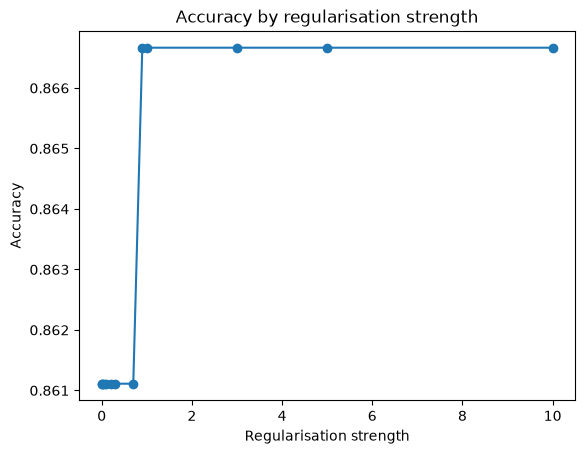

In [14]:
import matplotlib.pyplot as plt

from src.model_with_reg import LogisticRegressionScratchWithReg
from src.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    confusion_matrix_labelled,
)

reg_strengths = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.7, 0.9, 1.0, 3.0, 5.0, 10.0]

results = []

for strength in reg_strengths:
    model = LogisticRegressionScratchWithReg(
        learning_rate=0.01,
        n_iters=1000,
        reg_strength=strength
    )

    model.fit(X_train_scaled, Y_train)
    preds = model.predict(X_test_scaled)

    accuracy = accuracy_score(Y_test, preds)
    recall = recall_score(Y_test, preds)
    precision = precision_score(Y_test, preds)
    f1 = f1_score(Y_test, preds)

    results.append({
        "reg_strength": strength,
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1": f1
    })

    print(f"Current Strength: {strength}")
    print("Accuracy:", accuracy)
    print("Recall:", recall)
    print("Precision:", precision)
    print("F1:", f1)
    print(confusion_matrix_labelled(Y_test, preds))
    print()

accuracies = [row["accuracy"] for row in results]

plt.plot(reg_strengths, accuracies, marker="o")
plt.xlabel("Regularisation strength")
plt.ylabel("Accuracy")
plt.title("Accuracy by regularisation strength")
plt.show()